#### Task-7. Replace the optimizer in Part B with torch.optim.Adam and compare its convergence behavior with SGD. 

In [67]:
import torch
from torch import nn

import numpy as np
import matplotlib.pyplot as plt

In [68]:
X = np.arange(0, 1, 0.02)
y = 5.66*X + 3.227

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train, y_train = torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float()
X_test, y_test = torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float()

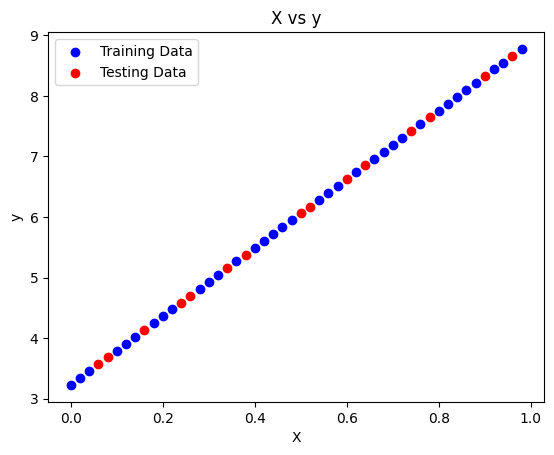

In [69]:
def plot_data(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, predictions=None):
    plt.scatter(X_train, y_train, c='b', label='Training Data')
    plt.scatter(X_test, y_test, c='r', label='Testing Data')
    if predictions is not None:
        plt.plot(X_test, predictions, c='g', label='Predictions')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title('X vs y')
    plt.legend(); 
    plt.show()
plot_data()

In [70]:
class LinearRegressionNetwork(nn.Module): #base class -> nn.module
    def __init__(self):
        super().__init__() # initializes everything that PyTorch needs internally

        # requires_grad=True tells PyTorch to track every operation performed on that tensor so it can automatically compute gradients during backpropagation and update the parameter to reduce the loss.
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float)) 
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))     

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights*x + self.bias

In [71]:
torch.manual_seed(42)
model_1 = LinearRegressionNetwork()
model_1.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

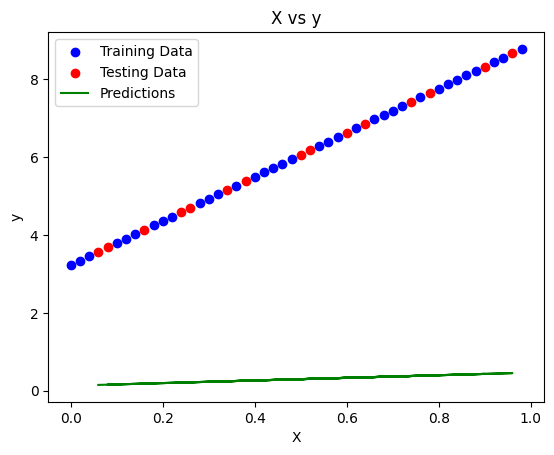

In [72]:
# to make predictions on the test data without calculating gradients
with torch.inference_mode():
    y_pred = model_1(X_test)
plot_data(predictions=y_pred)

In [73]:
loss_fn = nn.MSELoss()

# tells the model how to adjust its weights and bias to reduce that error.
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.1) 

In [74]:
epochs = 200
train_loss_list, test_loss_list = [], []
for epoch in range(epochs):
    # forward pass
    model_1.train()
    train_pred = model_1(X_train)

    # Calculate loss
    loss = loss_fn(y_train, train_pred)

    # Zero gradients
    optimizer.zero_grad() # Clear old gradients

    #back propagation
    loss.backward()

    # Update parameters
    optimizer.step()
    
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        test_loss = loss_fn(y_test, test_pred)
    train_loss_list.append(loss.detach().numpy())
    test_loss_list.append(test_loss.detach().numpy())
    if epoch%10 == 0:
        print(f"Epoch {epoch+1}| Train Loss {loss:.6f}| test loss {test_loss:.6f}")

Epoch 1| Train Loss 35.309525| test loss 32.303547
Epoch 11| Train Loss 19.707977| test loss 17.688450
Epoch 21| Train Loss 9.221455| test loss 8.048893
Epoch 31| Train Loss 3.394644| test loss 2.839620
Epoch 41| Train Loss 0.922773| test loss 0.726884
Epoch 51| Train Loss 0.234741| test loss 0.191898
Epoch 61| Train Loss 0.160885| test loss 0.158669
Epoch 71| Train Loss 0.169728| test loss 0.170076
Epoch 81| Train Loss 0.152088| test loss 0.149499
Epoch 91| Train Loss 0.128093| test loss 0.123595
Epoch 101| Train Loss 0.111933| test loss 0.106283
Epoch 111| Train Loss 0.100841| test loss 0.094728
Epoch 121| Train Loss 0.090848| test loss 0.085030
Epoch 131| Train Loss 0.081211| test loss 0.076119
Epoch 141| Train Loss 0.072234| test loss 0.067898
Epoch 151| Train Loss 0.063999| test loss 0.060263
Epoch 161| Train Loss 0.056450| test loss 0.053162
Epoch 171| Train Loss 0.049558| test loss 0.046634
Epoch 181| Train Loss 0.043311| test loss 0.040715
Epoch 191| Train Loss 0.037685| test l

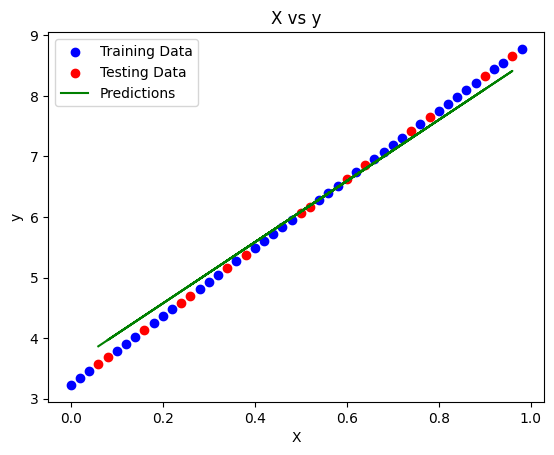

In [75]:
with torch.inference_mode():
    y_pred = model_1(X_test)
plot_data(predictions=y_pred)

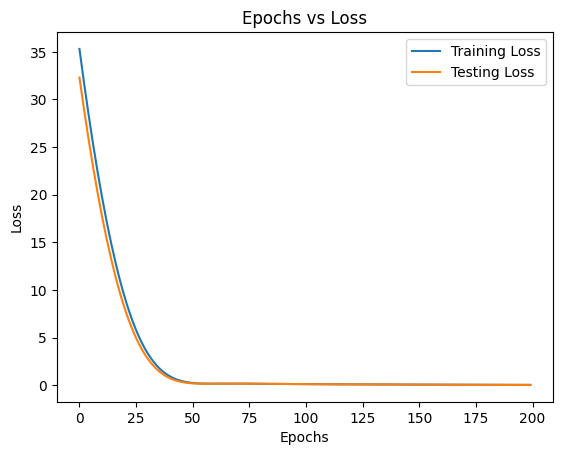

In [76]:
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.title("Epochs vs Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [77]:
print("Training Finished!")
print(f"Final Weight: {model_1.weights.item():.4f}")
print(f"Final Bias: {model_1.bias.item():.4f}")

Training Finished!
Final Weight: 5.0512
Final Bias: 3.5615
